In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('airnb.csv')

# Display the first few row
df.head()


,Title,Detail,Date,Price(in dollar),Offer price(in dollar),Review and rating,Number of bed
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.00,229.00,4.85 (531),4 beds
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.00,170.00,4.77 (146),4 beds
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.00,522.00,4.91 (515),4 beds
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.00,348.00,4.94 (88),5 beds
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.00,196.00,4.99 (222),1 queen bed


In [6]:
df.tail()

,Title,Detail,Date,Price(in dollar),Offer price(in dollar),Review and rating,Number of bed
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.00,NaN,4.85 (82),1 king bed
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.00,NaN,4.9 (300),1 king bed
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.00,NaN,4.92 (282),5 beds
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.00,NaN,4.96 (318),4 beds
952,Room in Long Beach,Across the Street from Beach Getaway/Near Conv...,May 1 - 6,106.00,NaN,4.85 (97),4 beds


In [7]:
df.shape

(953, 7)

In [9]:
df.isnull().sum()

Title                       0
Detail                      0
Date                        0
Price(in dollar)            0
Offer price(in dollar)    787
Review and rating           6
Number of bed               0
dtype: int64

In [10]:
# Drop duplicates if any
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 952
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Title                   919 non-null    object
 1   Detail                  919 non-null    object
 2   Date                    919 non-null    object
 3   Price(in dollar)        919 non-null    object
 4   Offer price(in dollar)  166 non-null    object
 5   Review and rating       913 non-null    object
 6   Number of bed           919 non-null    object
dtypes: object(7)
memory usage: 57.4+ KB


In [14]:
df.describe()

,Title,Detail,Date,Price(in dollar),Offer price(in dollar),Review and rating,Number of bed
count,919,919,919,919,166,913,919
unique,756,839,204,322,108,754,33
top,"Apartment in Kuala Lumpur, Malaysia","Lovely Private Room-Manhattan, 70s-Upper East ...",May 1 - 6,111.00,66.00,New,2 beds
freq,6,3,209,12,4,16,208


In [15]:
df.dtypes

Title                     object
Detail                    object
Date                      object
Price(in dollar)          object
Offer price(in dollar)    object
Review and rating         object
Number of bed             object
dtype: object

In [17]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Title'] = label_encoder.fit_transform(df['Title'])
df['Detail'] = label_encoder.fit_transform(df['Detail'])
df['Date'] = label_encoder.fit_transform(df['Date'])
df['Price(in dollar)'] = label_encoder.fit_transform(df['Price(in dollar)'])
df['Offer price(in dollar)'] = label_encoder.fit_transform(df['Offer price(in dollar)'])
df['Review and rating '] = label_encoder.fit_transform(df['Review and rating'])
df['Number of bed'] = label_encoder.fit_transform(df['Number of bed'])

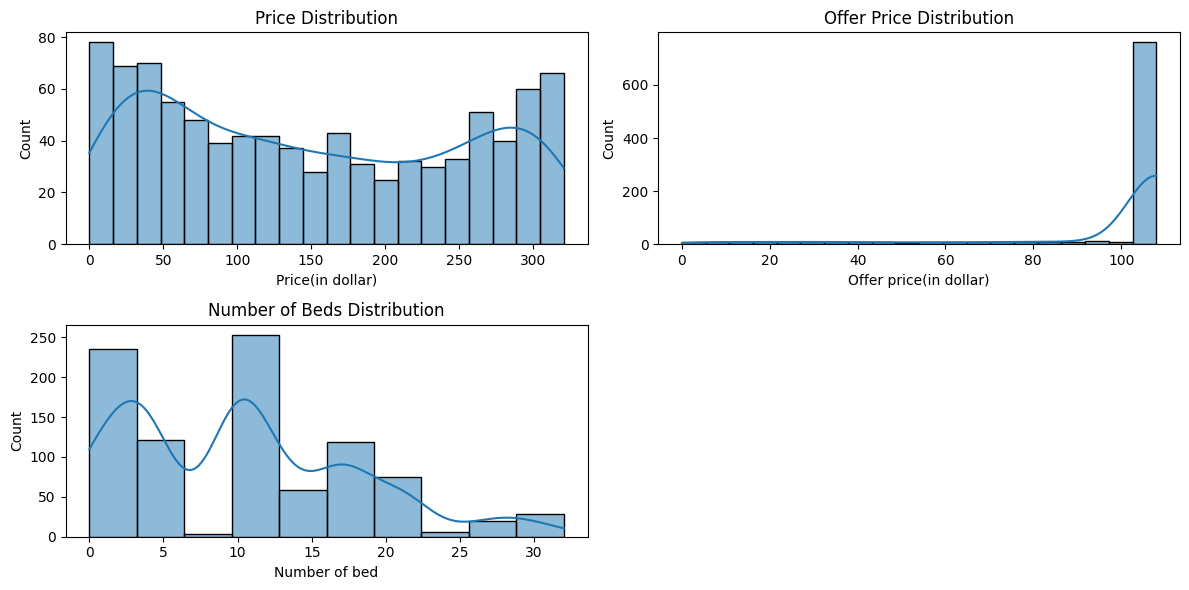

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical variables
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
sns.histplot(df['Price(in dollar)'], bins=20, kde=True)
plt.title('Price Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['Offer price(in dollar)'], bins=20, kde=True)
plt.title('Offer Price Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['Number of bed'], bins=10, kde=True)
plt.title('Number of Beds Distribution')

plt.tight_layout()
plt.show()


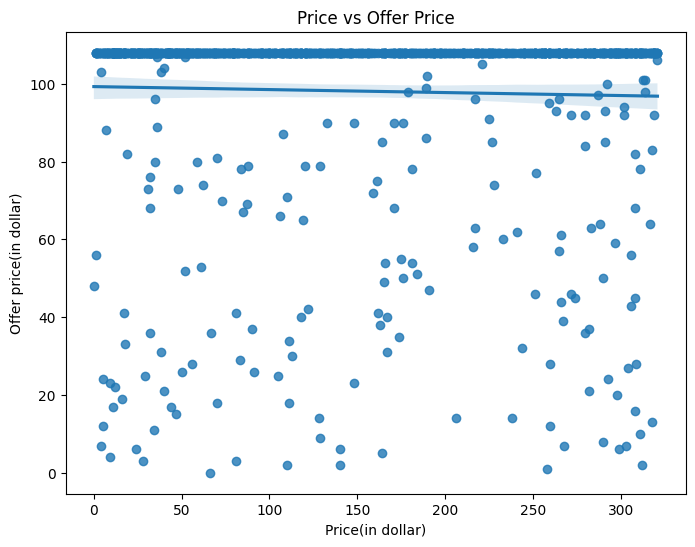

In [19]:
# Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='Price(in dollar)', y='Offer price(in dollar)', data=df)
plt.title('Price vs Offer Price')
plt.show()


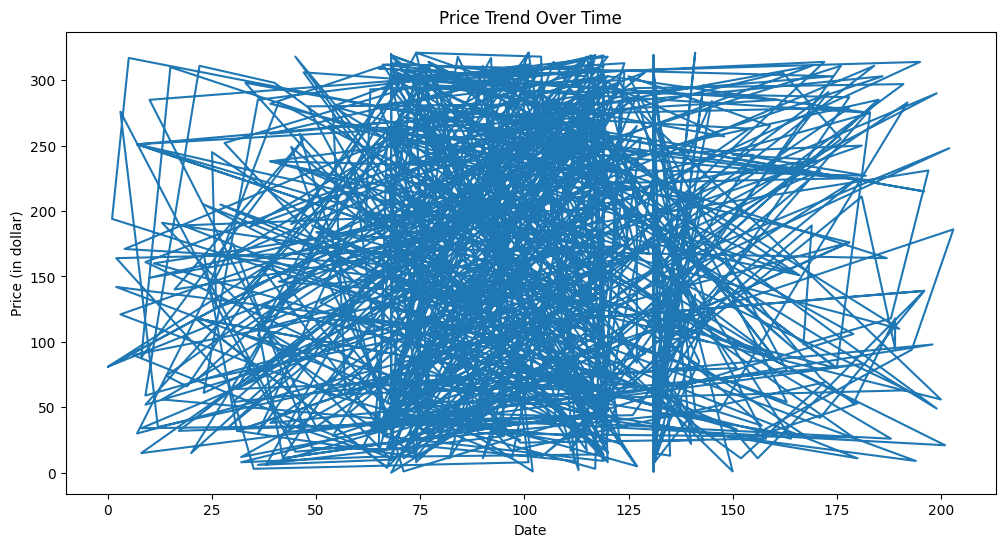

In [20]:
# Time series plot
plt.figure(figsize=(12, 6))
df.set_index('Date')['Price(in dollar)'].plot()
plt.title('Price Trend Over Time')
plt.ylabel('Price (in dollar)')
plt.show()


In [25]:
# Convert the DataFrame to JSON format
json_file_path = 'airnb.json'
df.to_json(json_file_path, orient='records', date_format='iso', indent=4)

print(f'Data has been successfully converted to JSON and saved to {json_file_path}')

Data has been successfully converted to JSON and saved to airnb.json
